# Week 4 Day 2: Core Supervised Learning: Preprocessing, Models & Evaluation
### Goal: 
To make repeatable pipelines

Preprocessing the data

Training two supervised models: logistic regression and decision trees

Evaluate on Hold-Out Test

### Dataset (same as before)

We are using the Adult Census Income Dataset.

Some stuff we did yesterday:

* 0 = <=50K
* 1 = >50K

## Stuff from Day 1

## Imports and Loading


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#For task 1: preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay


In [2]:
adult = fetch_openml(
    name="adult",
    version=2,              #apparently the second version doesnt have any ? so thats why i wasnt able to "clean" that
    as_frame=True
)

df = adult.frame.copy()
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.rename(columns={"class": "income"}, inplace=True)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [6]:
df["income"] = df["income"].map({"<=50K" : 0, ">50K" : 1})   #mapping it just like day1

In [8]:
df.duplicated().sum()

np.int64(52)

In [7]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [9]:
df.shape

(48842, 15)

### Issues from day 1
1. **Missing categories** in workclass, occupation, native_country (~2-6% each)
2. **Categorical encoding**: we might need one-hot encoding for workclass, education,
   marital_status, occupation, relationship, race, sex, native_country before feeding a actual model
3. **Skewed numerics**: capital_gain and capital_loss are extremely skewed
4. **Redundant features**: education (categorical) and education_num (numerical) have the same info so we might wanna keep just one
5. **fnlwgt** can be dropped since it does nothing for us
6. **Age is Nonlinear:** earning power vs. age is not linear, will have to look into that too
7. **? Mystery** Tried to find it but didnt get it, not sure if its an issue tho
8. Apparently there are 52 duplicates


Ill do a few of these these in the next few cells during cleaning and preprocessing
Wont touch the 3rd one yet (skewed numerics) since thats not part of today's task. Although we could use `log1p()` to fix it.


### Splitting from Day 1

Also, im gonna preprocess a little before splitting. Since thats normally what the workflow is. Even though it says to use the split from Day 1, theres still a need for preprocessing. So lets get into it

In [11]:
X = df.drop("income", axis=1)
y = df["income"]

In [12]:
# Dropping columns that we wont need 
X = X.drop(columns=["education", "fnlwgt"])

In [16]:
# splitting 80-20 (cant use it rn) (DONT TOUCH THIS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y) 

In [14]:
#optional dev split
X_train, X_dev, y_train, y_dev = train_test_split( X_train, y_train, test_size=0.10, stratify=y_train, random_state=42)

In [15]:
print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Test:", X_test.shape)

Training: (35165, 12)
Development: (3908, 12)
Test: (9769, 12)


In [ ]:
print(y_train.value_counts(normalize=True))
print(y_dev.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

#### Need for a hold-out test and what goes wrong if you use it during hyperparameter tuning
The hold-out test set is kept separate so we can measure how well the model performs on unseen data.

If we leak the test set into tuning, we pretty much lose our only unbiased check and risk deploying a model that looks great in development but underperforms in production

### Baselines from Day 1
### Baseline 1: Majority-Class Predictor
this'll predict the most common class

In [48]:
majority_class = y.mode()[0]
print(f"The majority class is: {majority_class}")

The majority class is: 0


In [49]:
y_pred_majority = np.full(len(y_test), majority_class)

### Baseline 2: Rule-Based Classifier (Single-feature)
Going for Captial Gain as the final one

In [50]:
y_pred_rule_cap_gain = (X_test["capital-gain"] > 0).astype(int)

In [57]:
# Evaluation Model from day 1
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_pred),
        "PR AUC": average_precision_score(y_true, y_pred)
    }

In [51]:
majority_results = evaluate_model(y_test, y_pred_majority)
capital_gain_rule_results = evaluate_model(y_test, y_pred_rule_cap_gain)

metrics = pd.DataFrame(
    [majority_results, capital_gain_rule_results],
    index=["Majority Class", "Capital Gain Rule"]
)

metrics.round(3)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Majority Class,0.761,0.000,0.000,0.000,0.500,0.239
Capital Gain Rule,0.782,0.625,0.225,0.331,0.591,0.326


### Justifying Capital Gain Rule as the Rule-Based Classifier
I chose captial gain rule since any investment income at all is a strong signal of financial means, So it works as a simple, interpretable rule-based classifier

## Task 1: Preprocessing Plan & Implementation
Already checked for ?, there are none. We shall start with this

### Listing the numeric and categorical columns

In [17]:
numeric_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

#### Making the numeric Pipeline

In [42]:
# Median imputation is used because it is less affected by outliers than the mean.
# Since features like capital-gain and capital-loss are highly skewed, the median
# gives a better estimate for missing values. Mean imputation was considered but
# skipped because it can be influenced by extreme values. Learned that from the first few tasks XD

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [37]:
numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

#### Making the Categorical Pipeline
I wasn't sure what to use here so going to compare two strategies, most_frequent and missing

In [38]:
categorical_transformer_mf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [34]:
# using missing instead of most frequent
categorical_transformer_missing = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])



In [43]:


results = {}

for label, cat_pipeline in [("most_frequent", categorical_transformer_mf),
                            ("Missing category", categorical_pipeline_missing)]:

    preprocessor_variant = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", cat_pipeline, categorical_features),
    ])

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor_variant),
        ("classifier", LogisticRegression(solver="liblinear", random_state=42, max_iter=1000)),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = pipe.predict_proba(X_test)[:, 1]

    results[label] = evaluate_model(y_test, pred)

imputation_comparison = pd.DataFrame(results).T
imputation_comparison = imputation_comparison[["Accuracy","Precision","Recall","F1","ROC AUC","PR AUC"]].round(4)
imputation_comparison



,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
most_frequent,0.8526,0.7386,0.5945,0.6588,0.7642,0.5361
Missing category,0.8553,0.7455,0.6001,0.6649,0.7678,0.5431


#### So this concludes it, its better to use the missing pipelines for categorical features

#### FINAL CATEGORICAL PIPELINE


In [44]:
# Missing values are replaced with a new "Missing" category so the model can learn
# whether missing information has any relationship with income. OneHotEncoder is
# used because it converts categorical features into numeric values without creating
# any false ordering between categories. Label Encoding was considered but skipped
# because it would incorrectly assign an order to categories like occupations or workclass.

categorical_transformer = categorical_transformer_missing

In [40]:
categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'constant'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",'Missing'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation.

In [41]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

**Note:** I used a "Missing" category for categorical features instead of replacing them with the most common value. This keeps missing values as their own category, allowing the model to learn whether missing information is meaningful. I also compared it with most frequent imputation, and using a "Missing" category gave slightly better results across all evaluation metrics, including Precision (0.7455 vs. 0.7386), so I chose it for the rest of the project.

## Task 2: Training Two Supervised Models (in Pipelines)
### Logistic Regression Pipeline

In [65]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        solver="liblinear"  # this supports regularization and handles the sparse one-hot matrix well
    ))
])

#train
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Decision Tree Pipeline

In [66]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

#train
tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

As asked, I only fitted the models on the training set

## Task 3: Evaluating on Hold-Out Test (Multiple Metrics)

### Predictions

In [60]:
log_pred = logistic_pipeline.predict(X_test)
tree_pred = tree_pipeline.predict(X_test)  

#score
log_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
tree_prob = tree_pipeline.predict_proba(X_test)[:, 1]

In [61]:
log_pred

array([0, 0, 1, ..., 1, 0, 0], shape=(9769,))


### Mutiple Metrics and Comparison
**Using the `evaluate_model
_day2()` function from Day 1 +Day 2 combined and also using the capital gain baseline from Day 1**


In [69]:
def evaluate_model_day2(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),              #used prob score here
        "PR AUC": average_precision_score(y_true, y_prob)
    }

In [70]:
# baseline capital gain from day 1
baseline = {
    "Accuracy":0.782,
    "Precision":0.625,
    "Recall":0.225,
    "F1":0.331,
    "ROC AUC":0.591,
    "PR AUC":0.326
}

In [75]:
day2_results = pd.DataFrame([
    baseline,
    evaluate_model_day2(y_test, log_pred, log_prob),
    evaluate_model_day2(y_test, tree_pred, tree_prob)
], index=[
    "D1: Capital Gain Baseline",   #D1 is Day 1 same with D2
    "D2: Logistic Regression",
    "D2: Decision Tree"
])

day2_results.round(3)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
D1: Capital Gain Baseline,0.782,0.625,0.225,0.331,0.591,0.326
D2: Logistic Regression,0.855,0.745,0.600,0.665,0.905,0.765
D2: Decision Tree,0.823,0.640,0.599,0.619,0.775,0.512


#### It seems that logistic regression seems to have performed very well by far in all metrics

In [77]:
day2_results.round(3).to_csv("model_comparison_table.csv")

In [78]:
# gonna try precision@k too 
def precision_at_k(y_true, y_score, k):
    order = np.argsort(-np.asarray(y_score))[:k]
    y_true = np.asarray(y_true)
    return y_true[order].mean() if k > 0 else np.nan
    

#### Precision@k
Since precision@k is my main metric lets test this out there too

In [80]:
# Precision@K, since that's my primary metric from Day 1
k_values = [50, 100, 250, 500, 1000]
pak_table = pd.DataFrame({
    "K": k_values,
    "LogReg precision@K": [precision_at_k(y_test.values, log_prob, k) for k in k_values],
    "Tree precision@K": [precision_at_k(y_test.values, tree_prob, k) for k in k_values],
})
pak_table.to_csv("precision_at_k_day2.csv", index=False)
pak_table


,K,LogReg precision@K,Tree precision@K
0,50,1.000,0.640
1,100,1.000,0.680
2,250,0.996,0.660
3,500,0.928,0.644
4,1000,0.864,0.644


So the top 50 people predicted by the model were all actually high-income (1.00) by LogReg
Logistic Regression performed much better than the Decision Tree for Precision@K. It achieved 100% Precision for the top 50 and top 100 predictions. Although I don't know if that would count as overfitting. As K increased, the Precision gradually decreased because the model started including less confident predictions, but it still stayed much higher than the Decision Tree. 

Since Precision@K is my main metric for this project, Logistic Regression is still the stronger model

### Plotting ROC curves and Precision–Recall curves for both models
### ROC Curves

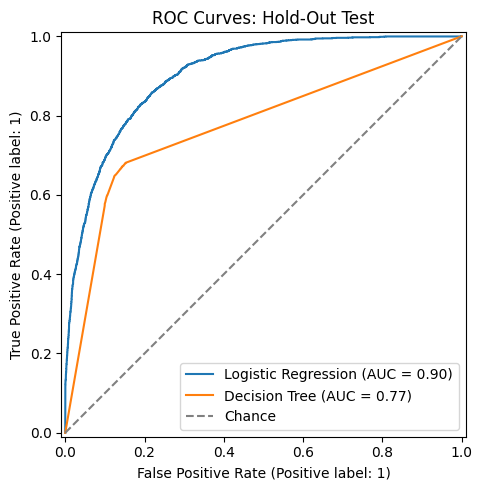

In [89]:
fig, ax = plt.subplots(figsize=(10, 5))
RocCurveDisplay.from_predictions(y_test, log_prob, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, tree_prob, name="Decision Tree", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_title("ROC Curves: Hold-Out Test")
ax.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curves

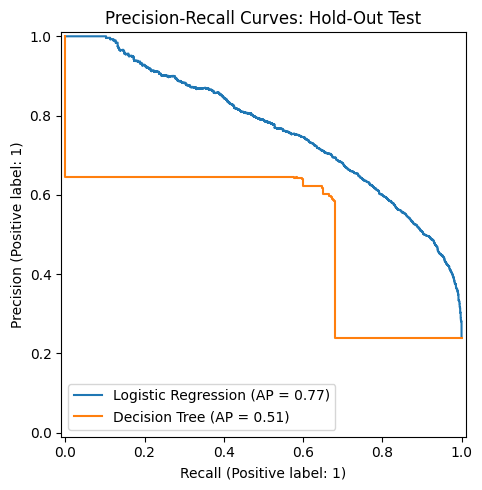

In [88]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, log_prob, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, tree_prob, name="Decision Tree", ax=ax)
ax.set_title("Precision-Recall Curves: Hold-Out Test")
plt.tight_layout()
plt.show()


### Confusion Metrics of Both Models

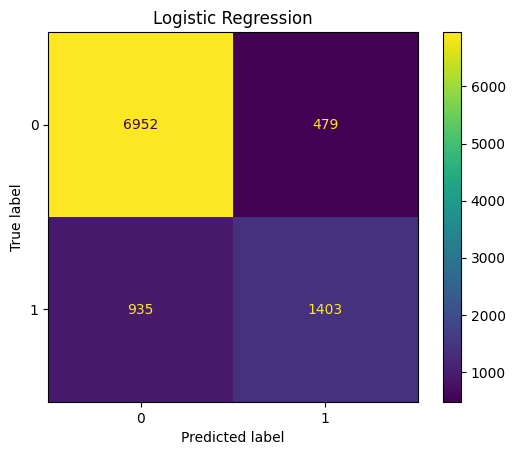

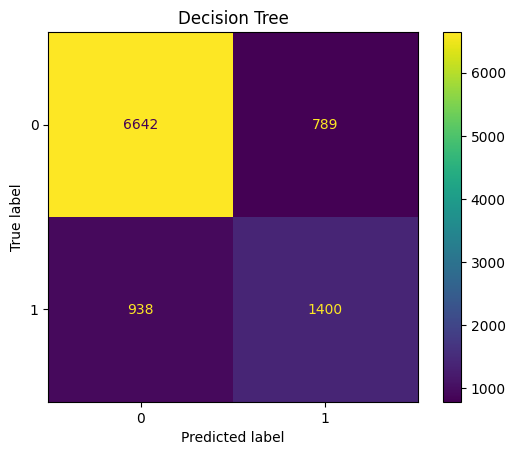

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, log_pred)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, tree_pred)
plt.title("Decision Tree")
plt.show()